# <a href="https://girafe.ai/" target="_blank" rel="noopener noreferrer"><img src="https://raw.githubusercontent.com/girafe-ai/ml-course/7096a5df4cada5ee651be1e3215c2f7fb8a7e0bf/logo_margin.svg" alt="girafe-ai logo" width="150px" align="left"></a> [ml-basic course](https://github.com/girafe-ai/ml-course) <a class="tocSkip">

# Lab assignment 01
## Data preprocessing, model training and evaluation

This lab assignment consists of several parts.

In this part you are supposed to work with tabular data: make some transformations, train some models, estimate the quality of the models and explain your results.

Several comments:
* Don't hesitate to ask questions in a chat, it's a good practice.
* No private/public sharing, please. The copied assignments will be graded with 0 points.
* Blocks of this lab will be graded separately.

## 1. Reading the data
Today we work with the [dataset](https://archive.ics.uci.edu/ml/datasets/Statlog+%28Vehicle+Silhouettes%29), describing different cars for multiclass ($k=4$) classification problem. The data is available below.

In [2]:
!pip install ucimlrepo

In [3]:
import ucimlrepo as uci
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [4]:
dataset = uci.fetch_ucirepo(id=149)

print(dataset.metadata.name, '\n')
print(dataset.metadata.abstract, '\n')
print(dataset.metadata.additional_info.summary, '\n')

Statlog (Vehicle Silhouettes) 

3D objects within a 2D image by application of an ensemble of shape feature extractors to the 2D silhouettes of the objects. 

The purpose is to classify a given silhouette as one of four types of vehicle, using  a set of features extracted from the silhouette. The vehicle may be viewed from one of many different angles.  

HISTORY:

This data was originally gathered at the TI in 1986-87 by JP Siebert. It was partially financed by Barr and Stroud Ltd. The original purpose was to find a method of distinguishing 3D objects within a 2D image by application of an ensemble of shape feature extractors to the 2D silhouettes of the objects. Measures of shape features extracted from example silhouettes of objects to be discriminated were used to generate a classification rule tree by means of computer induction.

This object recognition strategy was successfully used to discriminate between silhouettes of model cars, vans and buses viewed from constrained elevati

In [5]:
data = dataset.data.features
target = dataset.data.targets

print(data.shape, target.shape)

(846, 18) (846, 1)


In [6]:
target[target["class"]=="saab"]

,class
2,saab
9,saab
11,saab
18,saab
24,saab
...,...
834,saab
837,saab
841,saab
843,saab


### 1.1 Data integrity

Check if data is valid. If it is not, remove invalid parts.


In [7]:
data.isna().sum()

COMPACTNESS                         1
CIRCULARITY                         0
DISTANCE CIRCULARITY                0
RADIUS RATIO                        0
PR.AXIS ASPECT RATIO                0
MAX.LENGTH ASPECT RATIO             0
SCATTER RATIO                       0
ELONGATEDNESS                       0
PR.AXIS RECTANGULARITY              0
MAX.LENGTH RECTANGULARITY           0
SCALED VARIANCE ALONG MAJOR AXIS    0
SCALED VARIANCE ALONG MINOR AXIS    0
SCALED RADIUS OF GYRATION           0
SKEWNESS ABOUT MAJOR AXIS           0
SKEWNESS ABOUT MINOR AXIS           0
KURTOSIS ABOUT MINOR AXIS           0
KURTOSIS ABOUT MAJOR AXIS           0
HOLLOWS RATIO                       0
dtype: int64

One nan in comapactness, we will drop it

In [8]:
nan_idx=data[data["COMPACTNESS"].isna() == True].index.tolist()
data.drop(nan_idx, inplace=True)
target.drop(nan_idx, inplace=True)
data

/var/folders/cx/2dk5zlq93275n3kj7b8w85fc0000gn/T/ipykernel_81904/4072791440.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(nan_idx, inplace=True)
/var/folders/cx/2dk5zlq93275n3kj7b8w85fc0000gn/T/ipykernel_81904/4072791440.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target.drop(nan_idx, inplace=True)


,COMPACTNESS,CIRCULARITY,DISTANCE CIRCULARITY,RADIUS RATIO,PR.AXIS ASPECT RATIO,MAX.LENGTH ASPECT RATIO,SCATTER RATIO,ELONGATEDNESS,PR.AXIS RECTANGULARITY,MAX.LENGTH RECTANGULARITY,SCALED VARIANCE ALONG MAJOR AXIS,SCALED VARIANCE ALONG MINOR AXIS,SCALED RADIUS OF GYRATION,SKEWNESS ABOUT MAJOR AXIS,SKEWNESS ABOUT MINOR AXIS,KURTOSIS ABOUT MINOR AXIS,KURTOSIS ABOUT MAJOR AXIS,HOLLOWS RATIO
0,95.0,48,83,178,72,10,162,42,20,159,176,379,184,70,6,16,187,197
1,91.0,41,84,141,57,9,149,45,19,143,170,330,158,72,9,14,189,199
2,104.0,50,106,209,66,10,207,32,23,158,223,635,220,73,14,9,188,196
3,93.0,41,82,159,63,9,144,46,19,143,160,309,127,63,6,10,199,207
4,85.0,44,70,205,103,52,149,45,19,144,241,325,188,127,9,11,180,183
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
841,93.0,39,87,183,64,8,169,40,20,134,200,422,149,72,7,25,188,195
842,89.0,46,84,163,66,11,159,43,20,159,173,368,176,72,1,20,186,197
843,106.0,54,101,222,67,12,222,30,25,173,228,721,200,70,3,4,187,201
844,86.0,36,78,146,58,7,135,50,18,124,155,270,148,66,0,25,190,195


### 1.2 Train and test sets

Split data into 2 groups using `sklearn`'s infrastructure.

Which size of test set to choose?

In [9]:
from sklearn.model_selection import train_test_split
data_val = data
target_val = target
X_train, X_test, y_train, y_test = train_test_split(data_val, target_val, random_state = 1) # test size is default 0.25


In [10]:
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(633, 18) (633, 1) (212, 18) (212, 1)


To get some insights about the dataset, `pandas` might be used. The `train` part is transformed to `pd.DataFrame` below.

In [11]:
X_train_pd = pd.DataFrame(X_train)

# First 15 rows of our dataset.
X_train_pd.head(15)

,COMPACTNESS,CIRCULARITY,DISTANCE CIRCULARITY,RADIUS RATIO,PR.AXIS ASPECT RATIO,MAX.LENGTH ASPECT RATIO,SCATTER RATIO,ELONGATEDNESS,PR.AXIS RECTANGULARITY,MAX.LENGTH RECTANGULARITY,SCALED VARIANCE ALONG MAJOR AXIS,SCALED VARIANCE ALONG MINOR AXIS,SCALED RADIUS OF GYRATION,SKEWNESS ABOUT MAJOR AXIS,SKEWNESS ABOUT MINOR AXIS,KURTOSIS ABOUT MINOR AXIS,KURTOSIS ABOUT MAJOR AXIS,HOLLOWS RATIO
563,89.0,42,75,140,55,6,145,46,19,139,170,312,166,71,15,26,191,198
487,93.0,45,81,177,64,7,160,41,20,147,180,383,188,70,11,11,192,199
662,87.0,41,66,140,58,6,148,46,19,136,164,318,178,79,19,2,181,185
552,90.0,39,89,181,62,8,175,38,21,132,200,458,154,70,11,15,189,195
786,107.0,55,103,213,68,11,219,30,25,172,221,709,216,70,10,7,187,197
592,79.0,43,72,141,62,8,153,44,19,144,175,344,174,78,0,8,182,188
623,106.0,52,108,207,64,12,221,31,25,168,229,709,200,73,22,38,190,205
159,91.0,45,75,154,57,6,150,44,19,146,170,335,180,66,16,2,193,198
435,85.0,37,68,145,60,6,130,51,18,130,150,253,121,65,3,14,195,203
161,107.0,52,101,218,64,11,202,33,23,164,219,610,192,65,17,2,197,206


Methods `describe` and `info` deliver some useful information.

In [12]:
X_train_pd.describe()

,COMPACTNESS,CIRCULARITY,DISTANCE CIRCULARITY,RADIUS RATIO,PR.AXIS ASPECT RATIO,MAX.LENGTH ASPECT RATIO,SCATTER RATIO,ELONGATEDNESS,PR.AXIS RECTANGULARITY,MAX.LENGTH RECTANGULARITY,SCALED VARIANCE ALONG MAJOR AXIS,SCALED VARIANCE ALONG MINOR AXIS,SCALED RADIUS OF GYRATION,SKEWNESS ABOUT MAJOR AXIS,SKEWNESS ABOUT MINOR AXIS,KURTOSIS ABOUT MINOR AXIS,KURTOSIS ABOUT MAJOR AXIS,HOLLOWS RATIO
count,633.000000,633.000000,633.000000,633.000000,633.00000,633.000000,633.000000,633.000000,633.000000,633.000000,633.000000,633.000000,633.000000,633.000000,633.000000,633.000000,633.000000,633.000000
mean,93.799368,44.864139,82.289100,169.401264,61.64613,8.437599,169.224329,40.884676,20.608215,148.042654,188.860979,442.300158,174.872038,72.295419,6.453397,12.548183,189.009479,195.699842
std,8.247508,6.256176,15.901302,32.978514,7.08568,3.992435,33.770731,7.922347,2.633414,14.716404,31.571993,179.526474,32.907490,7.222477,4.998556,9.095205,6.103011,7.408831
min,76.000000,33.000000,40.000000,110.000000,47.00000,2.000000,112.000000,26.000000,17.000000,118.000000,130.000000,184.000000,109.000000,60.000000,0.000000,0.000000,176.000000,181.000000
25%,88.000000,40.000000,70.000000,141.000000,57.00000,6.000000,146.000000,33.000000,19.000000,137.000000,167.000000,317.000000,150.000000,67.000000,2.000000,5.000000,185.000000,191.000000
50%,93.000000,44.000000,80.000000,167.000000,62.00000,8.000000,157.000000,43.000000,20.000000,146.000000,178.000000,363.000000,173.000000,71.000000,6.000000,11.000000,189.000000,197.000000
75%,100.000000,50.000000,98.000000,197.000000,65.00000,10.000000,201.000000,46.000000,23.000000,160.000000,217.000000,602.000000,199.000000,75.000000,9.000000,19.000000,193.000000,201.000000
max,119.000000,59.000000,112.000000,306.000000,126.00000,52.000000,265.000000,61.000000,29.000000,188.000000,288.000000,1018.000000,268.000000,127.000000,22.000000,41.000000,206.000000,211.000000


In [13]:
X_train_pd.info()

<class 'pandas.core.frame.DataFrame'>
Index: 633 entries, 563 to 37
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   COMPACTNESS                       633 non-null    float64
 1   CIRCULARITY                       633 non-null    int64  
 2   DISTANCE CIRCULARITY              633 non-null    int64  
 3   RADIUS RATIO                      633 non-null    int64  
 4   PR.AXIS ASPECT RATIO              633 non-null    int64  
 5   MAX.LENGTH ASPECT RATIO           633 non-null    int64  
 6   SCATTER RATIO                     633 non-null    int64  
 7   ELONGATEDNESS                     633 non-null    int64  
 8   PR.AXIS RECTANGULARITY            633 non-null    int64  
 9   MAX.LENGTH RECTANGULARITY         633 non-null    int64  
 10  SCALED VARIANCE ALONG MAJOR AXIS  633 non-null    int64  
 11  SCALED VARIANCE ALONG MINOR AXIS  633 non-null    int64  
 12  SCALED RADIU

## 2. Machine Learning pipeline
Here you are supposed to perform the desired transformations. Please, explain your results briefly after each task.

### 2.0. Data preprocessing

Apply transformations to the dataset (if necessary).

Briefly explain the transformations

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_standardized = scaler.fit_transform(X_train)
X_test_standardized = scaler.transform(X_test)

remove mean and normalize dispersion

In [15]:
X_train_standardized

array([[-0.58237754, -0.45817189, -0.4587589 , ...,  1.48017057,
         0.3264119 ,  0.31070719],
       [-0.09699902,  0.02173347, -0.08113291, ..., -0.17035434,
         0.49039502,  0.44578799],
       [-0.8250668 , -0.61814034, -1.02519788, ..., -1.16066928,
        -1.31341932, -1.44534325],
       ...,
       [-0.21834365, -0.93807725,  0.54824373, ...,  1.15006559,
         0.49039502,  0.58086879],
       [-0.46103291,  0.50163883, -0.26994591, ...,  0.15975065,
        -1.1494362 , -0.49977763],
       [-0.46103291,  0.50163883,  0.23355541, ...,  0.26978564,
        -0.65748683, -0.22961603]], shape=(633, 18))

### 2.1. Basic logistic regression

* Find optimal hyperparameters for logistic regression with cross-validation on the `train` data (small grid/random search is enough, no need to find the *best* parameters).

* Estimate the model quality with `f1` and `accuracy` scores.
* Plot a ROC-curve for the trained model. For the multiclass case you might use `scikitplot` library (e.g. `scikitplot.metrics.plot_roc(test_labels, predicted_proba)`).

*Note: please, use the following hyperparameters for logistic regression:\
`multi_class='multinomial'`, `solver='saga'` `tol=1e-3` and ` max_iter=500`.*

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

hyperparams = [
    {'penalty': [None]},
    {'penalty': ['l1'], 'C': [0.1, 1, 10]},
    {'penalty': ['l2'], 'C': [0.1, 1, 10]},
    {'penalty': ['elasticnet'], 'C': [0.1, 1, 10, 100], 
     'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]}
]

gs = GridSearchCV(
    estimator = LogisticRegression(multi_class='multinomial', solver = 'saga', tol = 1e-3, max_iter = 500, random_state = 1),
    param_grid = hyperparams, scoring = 'accuracy',
    return_train_score = True
)
gs.fit(X_train_standardized, np.ravel(y_train))
    
print("Best Parameters:", gs.best_params_)
print("CV best score:", gs.best_score_)

/Users/furs/mipt_inf/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/furs/mipt_inf/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/furs/mipt_inf/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/furs/mipt_inf/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logisti

Best Parameters: {'C': 10, 'l1_ratio': 0.1, 'penalty': 'elasticnet'}
CV best score: 0.7835645544306962


/Users/furs/mipt_inf/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [17]:
from sklearn.metrics import accuracy_score, f1_score
logreg_model = gs.best_estimator_
y_pred = logreg_model.predict(X_test_standardized)
print(f"accuracy:", accuracy_score(y_test, y_pred))
print(f"F1-score:", f1_score(y_test, y_pred, average = 'macro'))

accuracy: 0.8254716981132075
F1-score: 0.8227908501493407


<Axes: title={'center': 'Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>

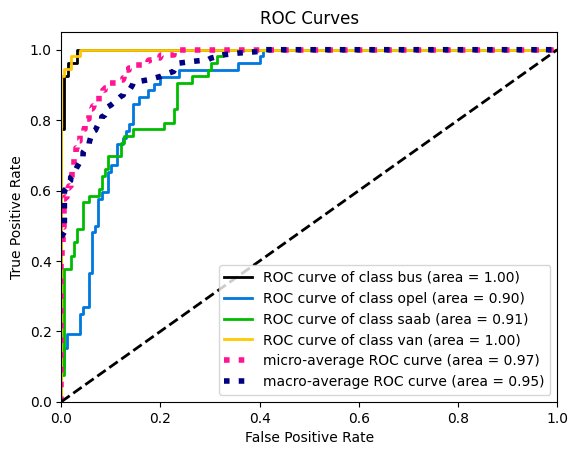

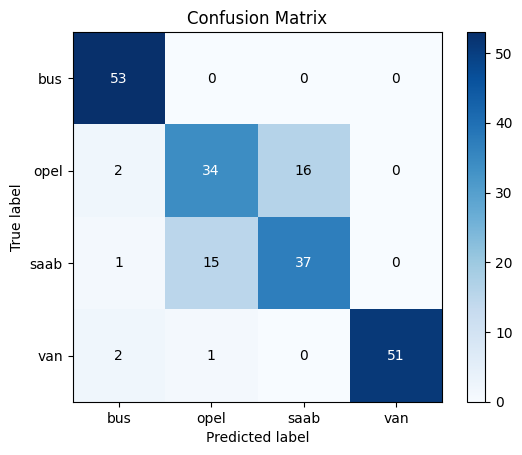

In [18]:
from scikitplot.metrics import plot_roc
from scikitplot.metrics import plot_confusion_matrix

y_probas = logreg_model.predict_proba(X_test_standardized)
plot_roc(y_test, y_probas)

plot_confusion_matrix(y_test, y_pred)

Я устал писать на английском. Модель иногда путает саабы и опели

### 2.2. PCA: explained variance plot

Apply the PCA to the train part of the data.

Build the explaided variance plot.

<Axes: title={'center': 'PCA Component Explained Variances'}, xlabel='First n principal components', ylabel='Explained variance ratio of first n components'>

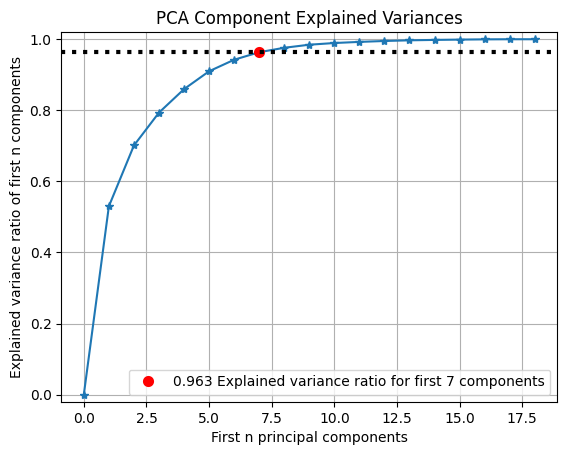

In [ ]:
from sklearn.decomposition import PCA
from scikitplot.decomposition import plot_pca_component_variance
pca_plot = PCA(random_state = 1)
pca_plot.fit(X_train_standardized)
plot_pca_component_variance(pca_plot, target_explained_variance  = 0.95)

### 2.3. PCA trasformation

Select the appropriate number of components.

Briefly explain your choice. Should you normalize the data?

*Use `fit` and `transform` methods to transform the `train`, `val` and `test` parts.*

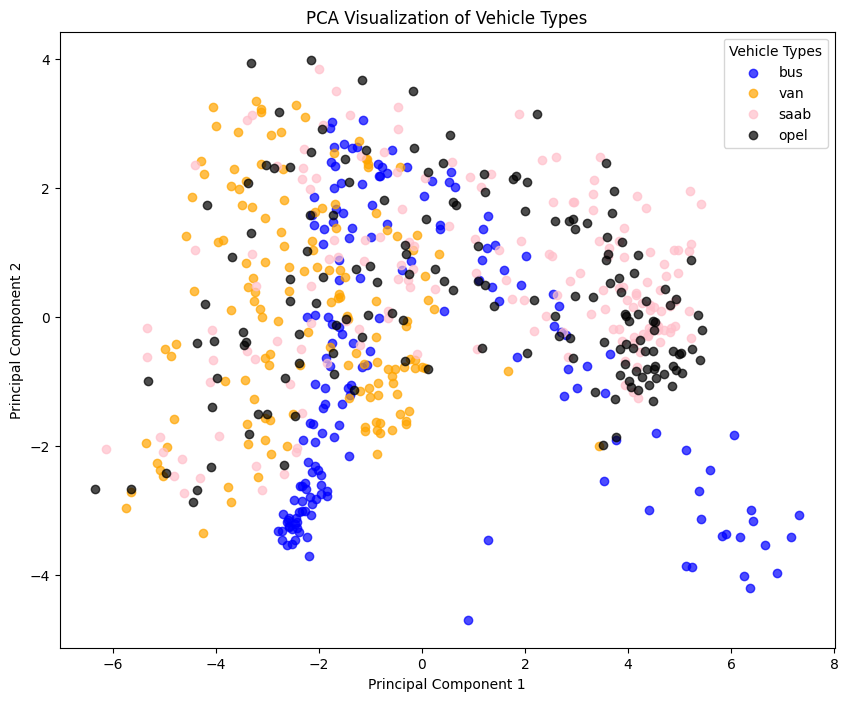

In [ ]:
import matplotlib.pyplot as plt
color_palette = {'bus': 'blue', 'van': 'orange', 'saab': 'pink', 'opel': 'black'}
colors = [color_palette[label] for label in np.ravel(y_train)]

pca_vis = PCA(random_state=1, n_components=2)
X_pca_vis = pca_vis.fit_transform(X_train_standardized)

plt.figure(figsize=(10, 8))

for vehicle_type, color in color_palette.items():
    mask = np.ravel(y_train) == vehicle_type
    plt.scatter(X_pca_vis[mask, 0], X_pca_vis[mask, 1], 
                c=color, label=vehicle_type, alpha=0.7)

plt.legend(title='Vehicle Types')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Visualization of Vehicle Types')
plt.show()

In [ ]:
pca = PCA(random_state = 1, n_components = 0.95)
X_pca_train = pca.fit_transform(X_train_standardized)
X_pca_test = pca.transform(X_test_standardized)

Took components that gives 95% info. Normalization is necessary to perform PCA

Note: From this point `sklearn` [Pipeline](https://scikit-learn.org/stable/modules/compose.html) might be useful to perform transformations on the data. Refer to the [docs](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) for more information.

### 2.4. Logistic regression on PCA-preprocessed data

* Find optimal hyperparameters for logistic regression with cross-validation on the transformed by PCA `train` data.
* Estimate the model quality with `f1` and `accuracy` scores.
* Plot a ROC-curve for the trained model. For the multiclass case you might use `scikitplot` library (e.g. `scikitplot.metrics.plot_roc(test_labels, predicted_proba)`).

*Note: please, use the following hyperparameters for logistic regression:\
`multi_class='multinomial'`, `solver='saga'` and `tol=1e-3`*

Best Parameters: {'C': 1, 'l1_ratio': 0.7, 'penalty': 'elasticnet'}
CV best score: 0.61453568303962
accuracy: 0.6273584905660378
F1-score: 0.6158053074230185


<Axes: title={'center': 'Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>

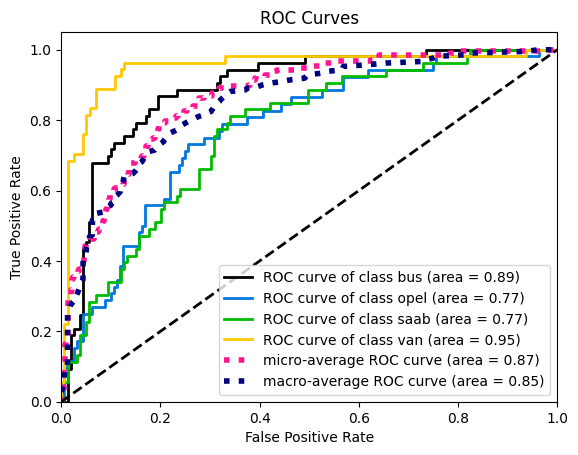

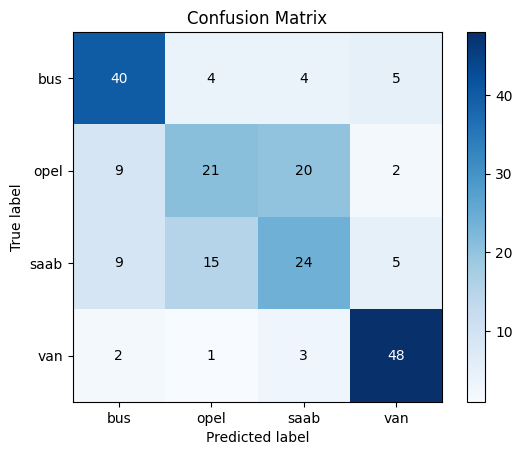

In [ ]:
hyperparams = [
    {'penalty': [None]},
    {'penalty': ['l1'], 'C': [0.1, 1, 10]},
    {'penalty': ['l2'], 'C': [0.1, 1, 10]},
    {'penalty': ['elasticnet'], 'C': [0.1, 1, 10,100], 
     'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]}
]
gs = GridSearchCV(estimator = LogisticRegression(solver = 'saga', tol = 1e-3, max_iter = 500),
                 param_grid = hyperparams, scoring = 'accuracy',
                  return_train_score = True)

gs.fit(X_pca_train, np.ravel(y_train))
print("Best Parameters:", gs.best_params_)
print("CV best score:", gs.best_score_)

#Estimating model quality
logreg_model = gs.best_estimator_
y_pred = logreg_model.predict(X_pca_test)
print(f"accuracy:", accuracy_score(y_test, y_pred))
print(f"F1-score:", f1_score(y_test, y_pred, average = 'macro'))

#Plotting ROC curve and confusion matrix
y_probas = logreg_model.predict_proba(X_pca_test)
plot_roc(y_test, y_probas)

plot_confusion_matrix(y_test, y_pred)

Потеряли в качестве модели (особенно для сааб и опель), но существенно выиграли в производительности.

### 2.5. Decision tree

* Now train a desicion tree on the same data. Find optimal tree depth (`max_depth`) using cross-validation.

* Measure the model quality using the same metrics you used above.

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
CV best score: 0.6461067366579177
accuracy: 0.6367924528301887
F1-score: 0.6401265935364205


<Axes: title={'center': 'Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>

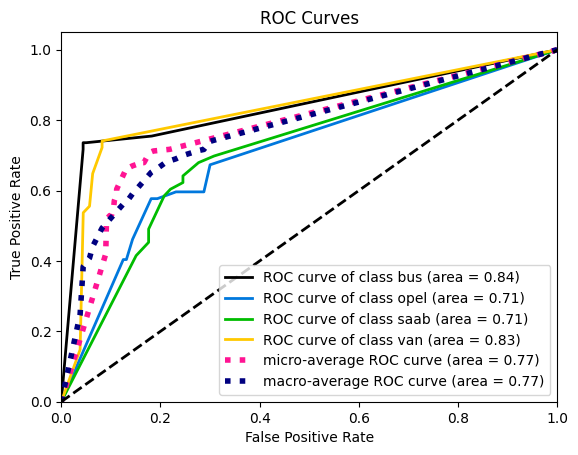

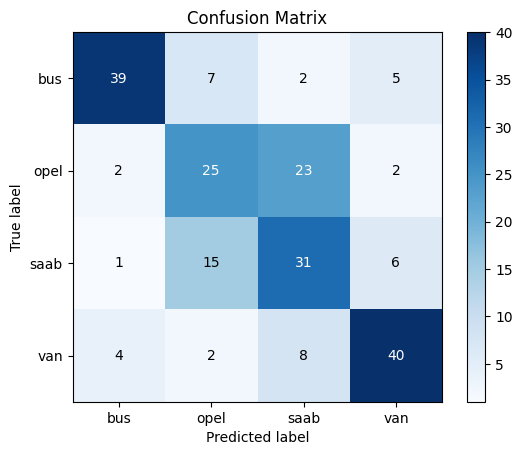

In [ ]:
from sklearn.tree import DecisionTreeClassifier

hyperparams = {
    'max_depth' : [2, 5, 10, 15, 20], 'min_samples_split' : [2, 3, 5, 7, 10],
    'min_samples_leaf' : [1, 2, 3, 5, 7]
}

gs = GridSearchCV(estimator = DecisionTreeClassifier(random_state = 1),
                 param_grid = hyperparams, scoring = 'accuracy',
                  return_train_score = True)

gs.fit(X_pca_train, y_train)

print("Best Parameters:", gs.best_params_)
print("CV best score:", gs.best_score_)

#Estimating model quality
tree_model = gs.best_estimator_
y_pred = tree_model.predict(X_pca_test)
print(f"accuracy:", accuracy_score(y_test, y_pred))
print(f"F1-score:", f1_score(y_test, y_pred, average = 'macro'))

#Plotting ROC curve and confusion matrix
y_probas = tree_model.predict_proba(X_pca_test)
plot_roc(y_test, y_probas)

plot_confusion_matrix(y_test, y_pred)

Получилось хуже чем с логистической, дополнительно - модель сильно чаще путает van и bus с остальными и между собой

### 2.6. Bagging

Here starts the ensembling part. You need to use [BaggingClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html)

First we will use the __Bagging__ approach. Build an ensemble of $N$ algorithms varying N from $N_{min}=2$ to $N_{max}=100$ with step 5.

We will build two ensembles: of logistic regressions and of decision trees.

*Comment: each ensemble should be constructed from models of the same family, so logistic regressions should not be mixed up with decision trees.*


*Hint 1: To build a __Bagging__ ensebmle varying the ensemble size efficiently you might generate $N_{max}$ subsets of `train` data (of the same size as the original dataset) using bootstrap procedure once. Then you train a new instance of logistic regression/decision tree with optimal hyperparameters you estimated before on each subset (so you train it from scratch). Finally, to get an ensemble of $N$ models you average the $N$ out of $N_{max}$ models predictions.*

*Hint 2: sklearn might help you with this taks. Some appropriate function/class might be out there.*

* Plot `f1` and `accuracy` scores plots w.r.t. the size of the ensemble.

* Briefly analyse the plot. What is the optimal number of algorithms? Explain your answer.

* How do you think, are the hyperparameters for the decision trees you found in 2.5 optimal for trees used in ensemble?

Max accuracy: 0.68 for N = 20
Max F1 score: 0.68 for N = 20


/Users/furs/mipt_inf/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/furs/mipt_inf/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/furs/mipt_inf/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/furs/mipt_inf/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/furs/mipt_inf/ml/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/furs/mipt_inf/ml/.venv/

Max accuracy: 0.63 for N = 25
Max F1 score: 0.62 for N = 25


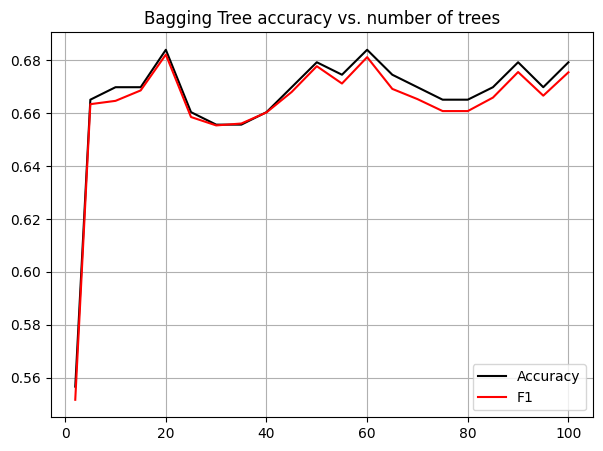

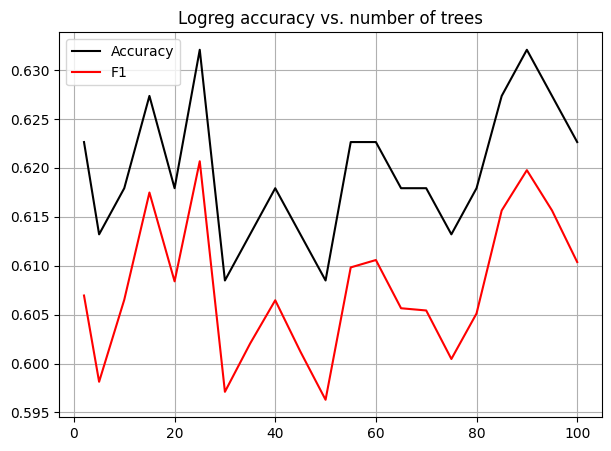

In [ ]:
from sklearn.ensemble import BaggingClassifier
import matplotlib.pyplot as plt
from scipy.stats import mode

def plot_accuracy(model, ensemble_sizes, title = None):
    accuracy = np.array([])
    f1_macro = np.array([])
    ensemble_pred = np.array([est.predict(X_pca_test) for est in model.estimators_])
    for ensemble_size in ensemble_sizes:
        y_pred = mode(ensemble_pred[:ensemble_size], axis = 0).mode
        y_pred = y_pred.astype(int)
        y_pred = model.classes_[y_pred]
        accuracy = np.append(accuracy, accuracy_score(y_test, y_pred))
        f1_macro = np.append(f1_macro, f1_score(y_test, y_pred, average = 'macro'))
    fig = plt.figure(figsize = (7, 5))
    plt.title(title)
    plt.plot(ensemble_sizes, accuracy, color = 'black', label = 'Accuracy')
    plt.plot(ensemble_sizes, f1_macro, color = 'red', label = 'F1')
    print(f'Max accuracy: {accuracy.max():.2f} for N = {ensemble_sizes[accuracy.argmax()]}')
    print(f'Max F1 score: {f1_macro.max():.2f} for N = {ensemble_sizes[f1_macro.argmax()]}')
    plt.grid()
    plt.legend()

N_min = 2
N_max = 100
increment = 5

ensemble_sizes = np.concatenate(([N_min], np.arange(5, N_max + 1, increment, dtype = int)),
                                dtype = int)
#TREE
bagging_tree = BaggingClassifier(estimator = tree_model, n_estimators = N_max, random_state = 1, max_samples=0.9)
bagging_tree.fit(X_pca_train, np.ravel(y_train))
plot_accuracy(bagging_tree, ensemble_sizes, 'Bagging Tree accuracy vs. number of trees')

#LOGREG
bagging_logreg = BaggingClassifier(estimator = logreg_model, n_estimators = N_max, random_state = 1, max_samples=0.9)
bagging_logreg.fit(X_pca_train, np.ravel(y_train))
plot_accuracy(bagging_logreg, ensemble_sizes, 'Logreg accuracy vs. number of trees')

Можно видеть, что для деревьев увеличение размера ансамбля дает позитивный эффект на значениях \approx 10-20 (эффект вообще наблюдается тк у деревьев большой variance), в то время как для логистической  не влияет на качество модели (тк у логистической и так низкий variance). (забавно, что два дерева работают хуже одного, а вот 10 уже лучше)

Мне кажется, что лучший набор гиперпараметров из п5 не обязательно будет лучшим для бэггинга, тк мы можем позволить себе больший variance (который уберет бэггинг) в обмен на уменьшенный bias 

### 2.7. Random Forest

Now we will work with the [Random Forest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html).

* Plot `f1` and `accuracy` scores plots w.r.t. the number of trees in Random Forest.

* What is the optimal number of trees you've got? Is it different from the optimal number of logistic regressions/decision trees in 2.6? Explain the results briefly.

Best Parameters: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2}
CV best score: 0.7077615298087739
Max accuracy: 0.71 for N = 100
Max F1 score: 0.70 for N = 100


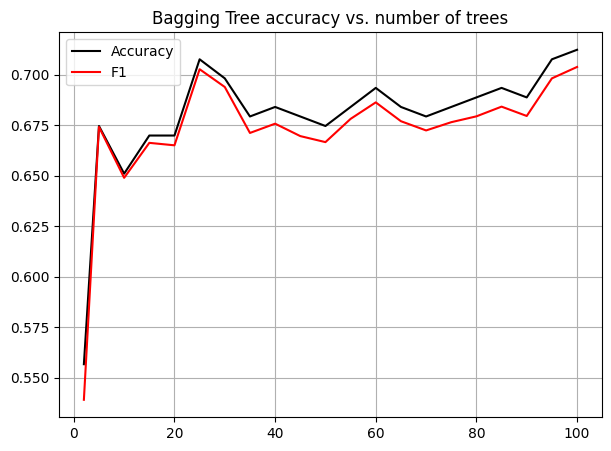

In [ ]:
from sklearn.ensemble import RandomForestClassifier

N_min = 2
N_max = 100
increment = 5

hyperparams = {
    'max_depth' : [2, 5, 7, 10, 15], 'min_samples_split' : [2, 3, 5],
    'min_samples_leaf' : [1, 2, 3]
}

gs = GridSearchCV(estimator = RandomForestClassifier(n_estimators = N_max, random_state = 1),
                 param_grid = hyperparams, scoring = 'accuracy',
                  return_train_score = True)

ensemble_sizes = np.concatenate(([N_min], np.arange(5, N_max + 1, increment, dtype = int)),
                                dtype = int)
gs.fit(X_pca_train, np.ravel(y_train))

print("Best Parameters:", gs.best_params_)
print("CV best score:", gs.best_score_)

rf_model = gs.best_estimator_
y_pred = rf_model.predict(X_pca_test)

plot_accuracy(rf_model, ensemble_sizes, 'Random Forest accuracy vs. number of trees')


У меня оптимальные количества деревьев не совпали, и как мне кажется, и не должны совпасть.

Значения получиличь немного лучше, чем для бэггинга деревьев

### 2.8. Learning curve

Your goal is to estimate, how does the model behaviour change with the increase of the `train` dataset size.

* Split the training data into 10 equal (almost) parts. Then train the models from above (Logistic regression, Desicion Tree, Random Forest) with optimal hyperparameters you have selected. First train it on first part, then on first and second parts combined (so the train size in increased by 2 times), first 3 parts and so on.

* You may use `sklearn`'s [readymade function](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.learning_curve.html). But note that you need to adjust parameters of this function appropriately.

* Build a plot of `accuracy` and `f1` scores on `test` part, varying the `train` dataset size (so the axes will be score vs dataset size).

* Analyse the final plot. Can you make any conlusions using it?

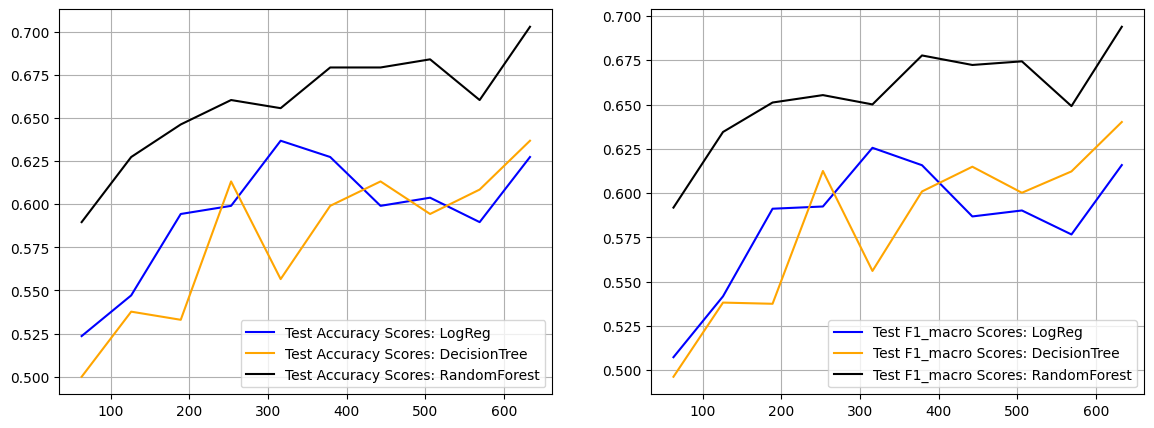

In [ ]:
def learning_curve(models:dict, X_train, X_test, y_train, y_test):
    train_size_abs = np.linspace(X_train.shape[0]//10, X_train.shape[0], 10).astype(int)
    color_palette = color_palette = ['blue', 'orange', 'black']
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for i, (model_name,model) in enumerate(models.items()):
        acc_score = []
        f1_macro_score = []
        
        for train_size in train_size_abs:
            model.fit(X_train[:train_size][:],y_train[:train_size])
            y_pred = model.predict(X_test)
            acc_score.append(accuracy_score(y_test, y_pred))
            f1_macro_score.append(f1_score(y_test, y_pred, average = 'macro'))
     
        axes[0].plot(train_size_abs, acc_score, color = color_palette[i],
                 label = 'Test Accuracy Scores: '+model_name)
        axes[1].plot(train_size_abs, f1_macro_score, color = color_palette[i],
                 label = 'Test F1_macro Scores: '+model_name)
     
    axes[0].grid()
    axes[1].grid()
    axes[0].legend()
    axes[1].legend()

learning_curve({'LogReg':logreg_model,'DecisionTree':tree_model, 'RandomForest':rf_model},
                    X_pca_train, X_pca_test, np.ravel(y_train), np.ravel(y_test))

Наверное основной вывод: на этой задаче лес работает ощутимо лучше логистической и дерева

### 2.9. Boosting

Apply [GradientBoostingClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html) to this problem.

Find optimal hyperparameters using [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) or RandomizedSearchCV.

Hyperparameters to consider:
* depth of each tree
* number of decision trees
* learning rate

Best Parameters: {'learning_rate': 0.5, 'max_depth': 3, 'n_estimators': 30}
CV best score: 0.70
Test accuracy: 0.72
Test macroF1-score: 0.72


<Axes: title={'center': 'Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>

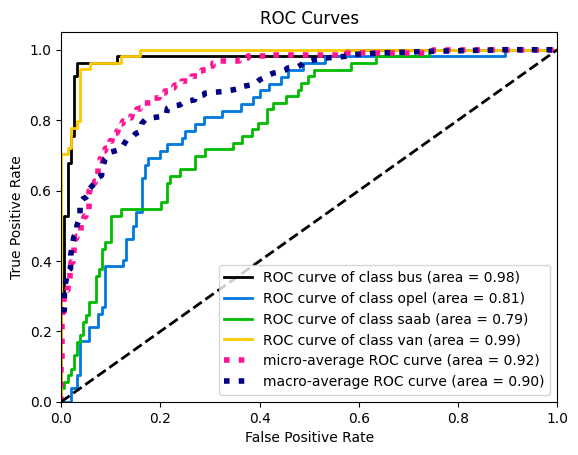

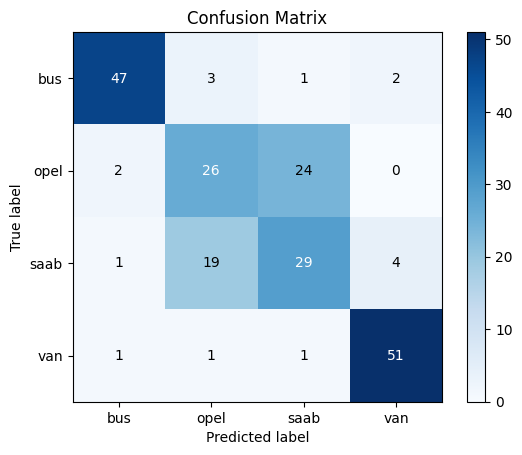

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

hyperparams = {
    'max_depth' : [2, 3, 5, 7], 'n_estimators' : [10, 30, 50],
    'learning_rate' : [1e-2, 1e-1, 0.5, 1, 2]
}

gs = GridSearchCV(estimator = GradientBoostingClassifier(random_state = 1),
                 param_grid = hyperparams, cv = 5, scoring = 'accuracy',
                  return_train_score = True)

gs.fit(X_pca_train, np.ravel(y_train))

print("Best Parameters:", gs.best_params_)
print(f"CV best score: {gs.best_score_:.2f}")

#Estimating model quality
gb_model = gs.best_estimator_
y_pred = gb_model.predict(X_pca_test)

print(f"Test accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"Test F1_macro-score: {f1_score(y_test, y_pred, average = 'macro'):.2f}")

#Plotting ROC curve and confusion matrix
y_probas = gb_model.predict_proba(X_pca_test)
plot_roc(y_test, y_probas)

plot_confusion_matrix(y_test, y_pred)